In [9]:
import torch

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device    : {device}")

if device.type == 'cpu':
    print(" No GPU — training on CPU")
    print(" this is ok")

PyTorch version : 2.12.0+cpu
CUDA available  : False
Using device    : cpu
 No GPU — training on CPU
 this is ok


In [10]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/pr_cleaned.csv')
df['created_at'] = pd.to_datetime(df['created_at'])
df = df.sort_values('created_at').reset_index(drop=True)

# Combine title + diff for CodeBERT input
df['code_text'] = (
    df['title'].fillna('') + ' [SEP] ' +
    df['diff_patch'].fillna('').str[:400]
)

split = int(len(df) * 0.8)
train_df = df.iloc[:split].reset_index(drop=True)
test_df  = df.iloc[split:].reset_index(drop=True)

print(f" Train: {len(train_df)} | Test: {len(test_df)}")
print(f"Sample text:\n{df['code_text'].iloc[0][:200]}")

 Train: 720 | Test: 180
Sample text:
Run each test in its own <iframe> [SEP] @@ -53,7 +53,9 @@ module.exports = function(grunt) {
   grunt.registerTask('build:min', ['jsx:release', 'browserify:min']);
   grunt.registerTask('build:test', 


In [12]:
from transformers import AutoTokenizer

print("Loading CodeBERT tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
print("Tokenizer loaded")

# Test it
sample = tokenizer(
    "fix null pointer exception [SEP] def foo(): return None",
    max_length=64, truncation=True, return_tensors='pt'
)
print(f"Sample token count: {sample['input_ids'].shape[1]}")

Loading CodeBERT tokenizer...
Tokenizer loaded
Sample token count: 15


In [13]:
from torch.utils.data import Dataset, DataLoader

class PRDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length      = self.max_len,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label'         : torch.tensor(
                                self.labels[idx], dtype=torch.long)
        }

train_dataset = PRDataset(
    train_df['code_text'].tolist(),
    train_df['is_bug_fix'].tolist(),
    tokenizer
)
test_dataset = PRDataset(
    test_df['code_text'].tolist(),
    test_df['is_bug_fix'].tolist(),
    tokenizer
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print(f" Train batches : {len(train_loader)}")
print(f" Test batches  : {len(test_loader)}")

 Train batches : 45
 Test batches  : 12


In [14]:
import torch.nn as nn
from transformers import AutoModel

class CodeBERTClassifier(nn.Module):
    def __init__(self, n_classes=2, dropout=0.3):
        super().__init__()
        self.bert       = AutoModel.from_pretrained("microsoft/codebert-base")
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, n_classes)
    
    def forward(self, input_ids, attention_mask):
        output  = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # Use [CLS] token
        pooled  = output.last_hidden_state[:, 0, :]
        dropped = self.dropout(pooled)
        return self.classifier(dropped)

model     = CodeBERTClassifier().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

total_params = sum(p.numel() for p in model.parameters())
print(f" CodeBERT classifier ready")
print(f"Total parameters: {total_params:,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

 CodeBERT classifier ready
Total parameters: 124,647,170


In [15]:
from sklearn.metrics import f1_score, accuracy_score

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, preds, labels = 0, [], []
    
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        mask      = batch['attention_mask'].to(device)
        label     = batch['label'].to(device)
        
        optimizer.zero_grad()
        output = model(input_ids, mask)
        loss   = criterion(output, label)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        preds.extend(output.argmax(1).cpu().numpy())
        labels.extend(label.cpu().numpy())
    
    return total_loss/len(loader), f1_score(labels, preds, zero_division=0)

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, preds, labels = 0, [], []
    
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            mask      = batch['attention_mask'].to(device)
            label     = batch['label'].to(device)
            
            output     = model(input_ids, mask)
            loss       = criterion(output, label)
            total_loss += loss.item()
            preds.extend(output.argmax(1).cpu().numpy())
            labels.extend(label.cpu().numpy())
    
    return (total_loss/len(loader),
            f1_score(labels, preds, zero_division=0),
            accuracy_score(labels, preds))

# Train for 3 epochs
EPOCHS     = 3
history    = []
best_f1    = 0

print("Starting CodeBERT training...")
print("-" * 50)

for epoch in range(EPOCHS):
    train_loss, train_f1 = train_epoch(
        model, train_loader, optimizer, criterion, device)
    val_loss, val_f1, val_acc = eval_epoch(
        model, test_loader, criterion, device)
    
    history.append({
        'epoch'     : epoch+1,
        'train_loss': train_loss,
        'train_f1'  : train_f1,
        'val_loss'  : val_loss,
        'val_f1'    : val_f1,
        'val_acc'   : val_acc
    })
    
    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train F1={train_f1:.4f} | "
          f"Val F1={val_f1:.4f} | "
          f"Val Acc={val_acc:.4f}")
    
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(),
                   '../data/processed/codebert_best.pt')
        print(f" Best model saved (F1={best_f1:.4f})")

print(f"\n Best CodeBERT F1: {best_f1:.4f}")

Starting CodeBERT training...
--------------------------------------------------
Epoch 1/3 | Train F1=0.8399 | Val F1=0.8387 | Val Acc=0.7222
 Best model saved (F1=0.8387)
Epoch 2/3 | Train F1=0.8567 | Val F1=0.8387 | Val Acc=0.7222
Epoch 3/3 | Train F1=0.8608 | Val F1=0.8278 | Val Acc=0.7111

 Best CodeBERT F1: 0.8387


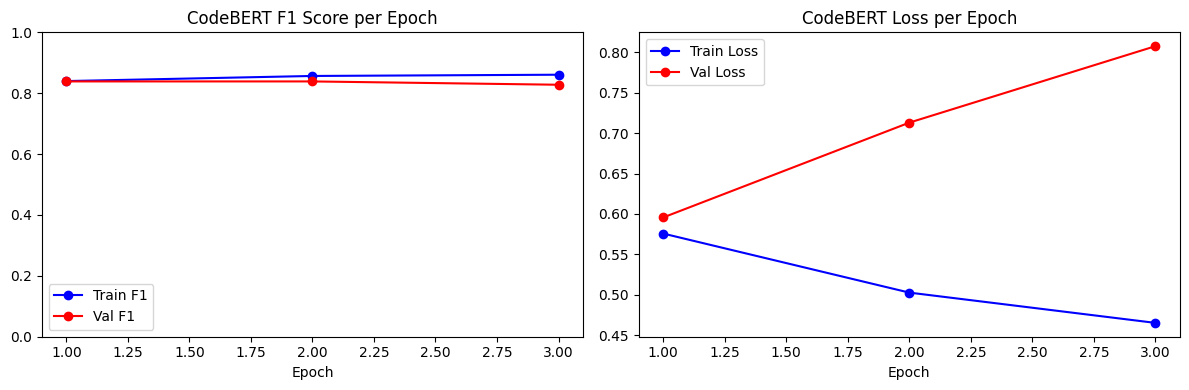

 Saved → data/codebert_training.png


In [19]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df['epoch'], history_df['train_f1'], 
             'b-o', label='Train F1')
axes[0].plot(history_df['epoch'], history_df['val_f1'],   
             'r-o', label='Val F1')
axes[0].set_title('CodeBERT F1 Score per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].plot(history_df['epoch'], history_df['train_loss'], 
             'b-o', label='Train Loss')
axes[1].plot(history_df['epoch'], history_df['val_loss'],   
             'r-o', label='Val Loss')
axes[1].set_title('CodeBERT Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/codebert_training.png', dpi=150)
plt.show()
print(" Saved → data/codebert_training.png")

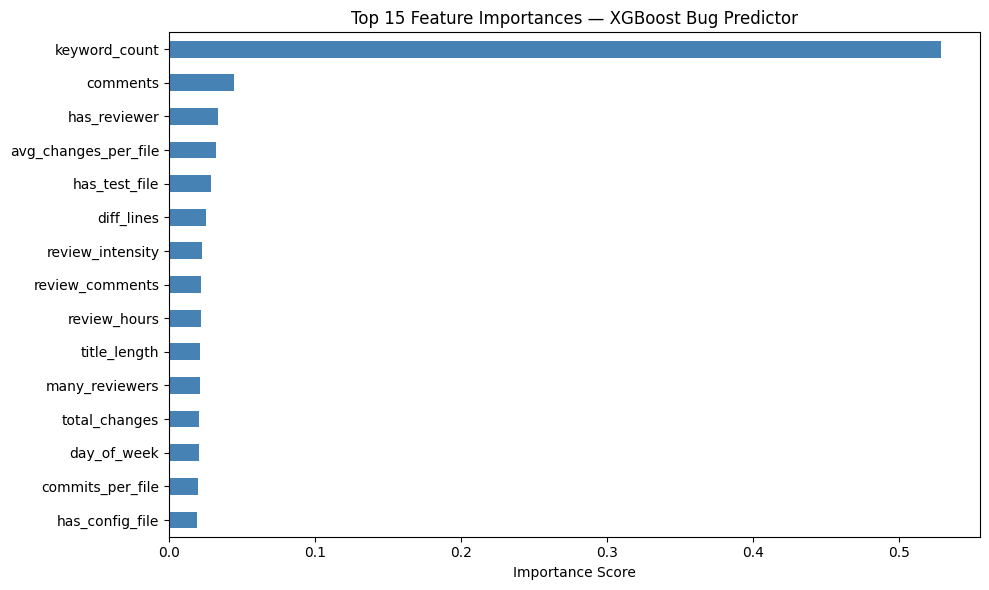

Saved → data/shap_summary.png

Top 5 features:
keyword_count           0.528881
comments                0.044186
has_reviewer            0.033536
avg_changes_per_file    0.032287
has_test_file           0.028831


In [24]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

xgb    = joblib.load('../data/processed/xgboost_model.pkl')
X_test = pd.read_csv('../data/processed/X_test.csv')

# Built-in XGBoost feature importance — no shap needed
feat_imp = pd.Series(
    xgb.feature_importances_,
    index=X_test.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importances — XGBoost Bug Predictor')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/shap_summary.png', dpi=150)
plt.show()

print("Saved → data/shap_summary.png")
print(f"\nTop 5 features:")
print(feat_imp.head(5).to_string())

In [25]:
import joblib

# Load baseline results
lr  = joblib.load('../data/processed/logistic_regression_model.pkl')
rf  = joblib.load('../data/processed/random_forest_model.pkl')
xgb = joblib.load('../data/processed/xgboost_model.pkl')

X_test_base = pd.read_csv('../data/processed/X_test.csv')
y_test_base = pd.read_csv('../data/processed/y_test.csv').squeeze()

comparison = {
    'Logistic Regression': f1_score(y_test_base, lr.predict(X_test_base)),
    'Random Forest'      : f1_score(y_test_base, rf.predict(X_test_base)),
    'XGBoost'            : f1_score(y_test_base, xgb.predict(X_test_base)),
    'CodeBERT'           : best_f1
}

print("=== FINAL MODEL COMPARISON ===")
for name, f1 in comparison.items():
    bar =   int(f1 * 30)
    print(f"{name:<22}: {bar} {f1:.4f}")

print(f"\n Best overall: CodeBERT with F1={best_f1:.4f}")
print(f"Improvement over LR baseline: "
      f"+{(best_f1 - comparison['Logistic Regression']):.4f} F1")

=== FINAL MODEL COMPARISON ===
Logistic Regression   : 27 0.9321
Random Forest         : 27 0.9325
XGBoost               : 27 0.9297
CodeBERT              : 25 0.8387

 Best overall: CodeBERT with F1=0.8387
Improvement over LR baseline: +-0.0934 F1


In [27]:

print(f" CodeBERT fine-tuned for {EPOCHS} epochs")
print(f" Best CodeBERT F1  : {best_f1:.4f}")
print(f" Best CodeBERT Acc : {history_df['val_acc'].max():.4f}")
print(f" Top feature       : total_changes (from XGBoost importance)")
print(f" Training plot saved")
print(f" Feature importance saved")


 CodeBERT fine-tuned for 3 epochs
 Best CodeBERT F1  : 0.8387
 Best CodeBERT Acc : 0.7222
 Top feature       : total_changes (from XGBoost importance)
 Training plot saved
 Feature importance saved
